# Task 1

### Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')

from google.colab import drive #for storing datasets in google drive for colab
drive.mount('/content/drive')

device: cuda
Mounted at /content/drive


### Task 1.1

In [2]:
EPOCHS=5

resnet_pretrained = models.resnet152(weights='DEFAULT')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

resnet_pretrained = resnet_pretrained.to(device)

training_loss = []
validation_loss= []

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

for i in range(EPOCHS):
    print(f'epoch: {i}')

    resnet_pretrained.train()
    curr_training_loss = 0

    for image, label in train_dataloder:
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        prediction = resnet_pretrained(image)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloder))
    print(f'training_loss: {curr_training_loss/len(train_dataloder)}')

    resnet_pretrained.eval()
    curr_validation_loss = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            curr_loss = loss(prediction, label)

            curr_validation_loss += curr_loss.item()

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    print(f'validation_loss: {curr_validation_loss/len(validation_dataloader)} \n')



Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:05<00:00, 47.9MB/s]


epoch: 0
training_loss: 1.060699812972637
validation_loss: 0.7353227129028101 

epoch: 1
training_loss: 0.6815424242897716
validation_loss: 0.6354192309318833 

epoch: 2
training_loss: 0.6174031875627425
validation_loss: 0.5962485261024184 

epoch: 3
training_loss: 0.5860998574501414
validation_loss: 0.5663615026671416 

epoch: 4
training_loss: 0.5609540276210326
validation_loss: 0.5509711999422425 



### Visualization for Task 1.1

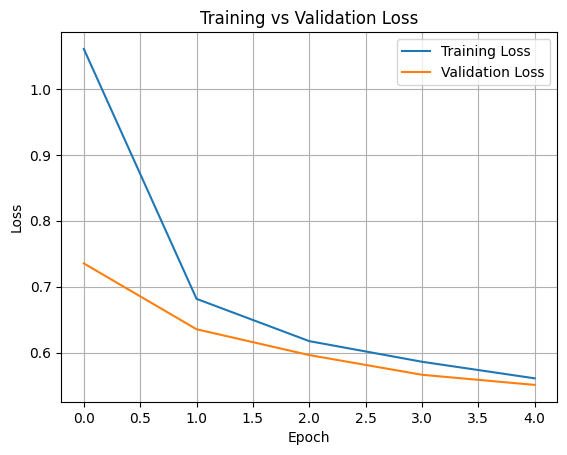

In [3]:
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.show()